In [15]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from pic0rick import device

In [17]:
p = device.Pic0rick()

Device on /dev/ttyACM0


In [18]:
# DSP (-DDSP) firmware build
print(p.version()['raw'])

pic0rick firmware v0.1.11
changes: Fix MUX/pulser PIO1 conflict: max14866_init hardcoded sm0, clobbering the pulser drive SM (pio1 sm0) claimed by the acquisition -- so MUX builds produced no transmit pulse / no echo. Now claims an unused SM. Restores echoes on MUX builds.
board:   pico2 (RP2350)
mux:     enabled (MAX14866)
build:   99e7b23-dirty
release: https://github.com/kelu124/pic0rick/releases/tag/fw-v0.1.11



In [19]:
# Set gain, configure + arm the pulser (so the capture transmits).
p.set_gain(50)
p.configure_pulse(negative_ns=200, damp_ns=2000, positive_ns=200, order='pos-first')
p.arm_pulser()

[b'OK pulser armed\r\n', b'']

OK capture started type=raw samples=8000 | samples 8000


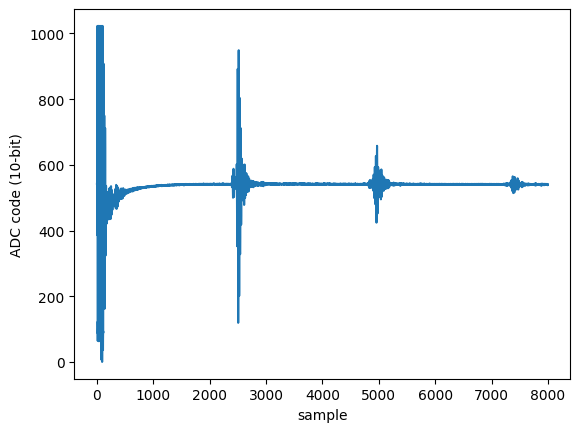

In [20]:
# read_raw -> 8000-sample raw ADC frame (CRC-checked). .samples() is a numpy
# uint16 array of 10-bit ADC codes (0..1023).
frame = p.read_raw()
signal = frame.samples()
print(p.last_reply, '| samples', frame.header.sample_count)
plt.plot(signal)
plt.xlabel('sample'); plt.ylabel('ADC code (10-bit)'); plt.show()

In [21]:
p.disarm_pulser()

[b'OK pulser disarmed\r\n', b'']